## Exercise 13: EDA on `hr_employee_data.xlsx`

**Task (from the book's exercise sheet):** "The dataset 'hr_employee_data.xlsx' contains
data related to a company's employees. Carry out an EDA and accompanying analysis,
imagining that the company's leadership team will review the analysis. In this exercise,
no ML modeling should be done (that will be done in the next chapter). 

Below is a complete EDA (exploratory data analysis) - **with no ML modeling** - on the
real dataset, with a summary analysis written for a leadership audience at the end.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_excel('hr_employee_data.xlsx')
df

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...,...
14994,IND40221,0.40,0.57,2,151,3,0,1,0,support,low
14995,IND24196,0.37,0.48,2,160,3,0,1,0,support,low
14996,IND33544,0.37,0.53,2,143,3,0,1,0,support,low
14997,IND40533,0.11,0.96,6,280,4,0,1,0,support,low


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB


In [9]:
print("Missing values per column:")
print(df.isna().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())
print("\nNumber of unique Emp_Id vs. number of rows:", df["Emp_Id"].nunique(), "vs", df.shape[0])

Missing values per column:
Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Number of duplicate rows: 0

Number of unique Emp_Id vs. number of rows: 14999 vs 14999


The dataset is complete - no missing values and no duplicates - and `Emp_Id` is a
unique identifier per row (one row per employee). The dataset contains **14,999
employees** and 11 columns: `satisfaction_level` (self-reported satisfaction, 0-1),
`last_evaluation` (latest performance score, 0-1), `number_project` (number of projects),
`average_montly_hours` (average monthly working hours), `time_spend_company` (years at
the company), `Work_accident` (whether the person has had a workplace accident), `left`
(whether the person has left - the **target variable** for next chapter's ML modeling),
`promotion_last_5years` (whether the person was promoted in the last 5 years), and
`Department` and `salary` (salary level: low/medium/high).

In [10]:
df.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Employee attrition - the overall picture

Share of employees who have left: 23.8%


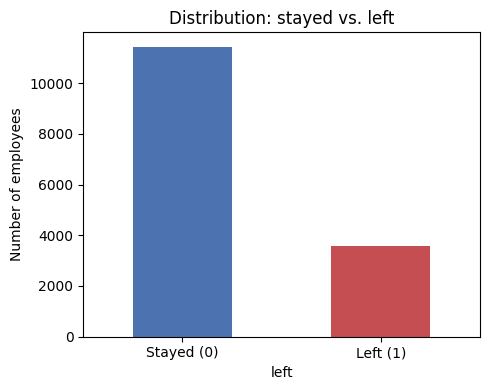

In [11]:
attrition_rate = df["left"].mean()
print(f"Share of employees who have left: {attrition_rate:.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
df["left"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Stayed (0)", "Left (1)"], rotation=0)
ax.set_ylabel("Number of employees")
ax.set_title("Distribution: stayed vs. left")
plt.tight_layout()
plt.show()


Nearly **24%** of the employees in the dataset have left. That's a high share and
justifies a deeper look into *why*.

### Satisfaction level - the single strongest signal

In [12]:
corr_with_left = df[[
    "satisfaction_level", "last_evaluation", "number_project",
    "average_montly_hours", "time_spend_company", "Work_accident",
    "promotion_last_5years", "left",
]].corr()["left"].sort_values()
print(corr_with_left)


satisfaction_level      -0.388375
Work_accident           -0.154622
promotion_last_5years   -0.061788
last_evaluation          0.006567
number_project           0.023787
average_montly_hours     0.071287
time_spend_company       0.144822
left                     1.000000
Name: left, dtype: float64


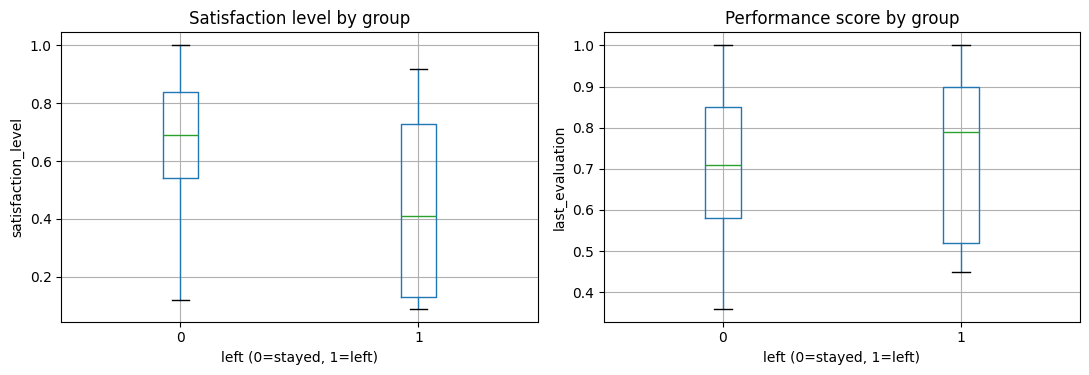

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.boxplot(column="satisfaction_level", by="left", ax=axes[0])
axes[0].set_xlabel("left (0=stayed, 1=left)")
axes[0].set_ylabel("satisfaction_level")
axes[0].set_title("Satisfaction level by group")

df.boxplot(column="last_evaluation", by="left", ax=axes[1])
axes[1].set_xlabel("left (0=stayed, 1=left)")
axes[1].set_ylabel("last_evaluation")
axes[1].set_title("Performance score by group")

plt.suptitle("")
plt.tight_layout()
plt.show()


Satisfaction level (`satisfaction_level`) has by far the strongest correlation with
`left` (about **-0.39**) of all the numeric variables - employees who leave report
noticeably lower satisfaction on average. The performance score (`last_evaluation`), on
the other hand, is essentially identical on average between the two groups (0.715 vs.
0.718) - but the boxplot reveals a much wider spread among those who left, which is
explored further below.